In [23]:
!pip install geobr

In [24]:
import requests
import pandas as pd
import geopandas as gpd
import geobr

# -------------------------
# Municípios
# -------------------------

municipios = geobr.read_municipality(year=2020)

# Manter apenas municípios do Pará
municipios = municipios[municipios["abbrev_state"] == "PA"].copy()


# -------------------------
# SIDRA
# -------------------------

url = (
    "https://apisidra.ibge.gov.br/values/"
    "t/5457/n6/all/v/214/p/last%201/c782/45982"
)

df = pd.read_json(url)

# Remove a primeira linha (cabeçalho da API)
df = df.iloc[1:].copy()

# Renomeia colunas
df = df.rename(columns={
    "D1C": "cod_municipio",
    "D1N": "municipio",
    "V": "producao_t"
})

# Converte tipos
df["cod_municipio"] = df["cod_municipio"].astype(str)
df["producao_t"] = pd.to_numeric(df["producao_t"], errors="coerce")

# -------------------------
# Merge
# -------------------------

municipios['code_muni'] = municipios['code_muni'].astype(int).astype(str)

# Note: pam was not defined in the current context, it should be 'df' here.
# Re-evaluating based on the latest notebook state:
# The previous code had a 'pam' DataFrame which was the result of a pivot_table operation.
# However, the current code in RRL2DJIRr8zx now uses 'df' directly from the API call after some cleaning.
# Therefore, the merge should be with 'df' and not 'pam'.
# I will use 'df' for the merge, consistent with the current cell's logic.
# I will also add a comment to clarify this potential confusion if 'pam' was expected.

gdf = municipios.merge(
    df[["cod_municipio", "producao_t"]],
    left_on="code_muni",
    right_on="cod_municipio",
    how="left"
)

gdf["producao_t"] = gdf["producao_t"].fillna(0)

# Re-project to a suitable projected CRS (e.g., a common UTM zone for Brazil or a global projection) for accurate centroid calculation
# The EPSG:3857 (Web Mercator) is a common projected CRS, but for high-precision area calculations, a more localized UTM zone might be better.
# For a country-wide context like Brazil, EPSG:3857 is often a reasonable compromise for visualization and approximate centroids.
# If higher precision is needed for area/distance across the whole country, one might consider using an Albers Equal Area Conic projection, or reprojecting to local UTM zones per state.
# For now, let's use a widely supported projected CRS like Web Mercator (EPSG:3857).
gdf_projected = gdf.to_crs(epsg=3857)

# Add a column for the centroids of the polygons using the projected GeoDataFrame
gdf['centroid'] = gdf_projected.geometry.centroid

print(gdf)

    code_muni           name_muni  code_state abbrev_state name_state  \
0     1500107          Abaetetuba        15.0           PA       Pará   
1     1500131     Abel Figueiredo        15.0           PA       Pará   
2     1500206               Acará        15.0           PA       Pará   
3     1500305                Afuá        15.0           PA       Pará   
4     1500347  Água Azul do Norte        15.0           PA       Pará   
..        ...                 ...         ...          ...        ...   
139   1508159              Uruará        15.0           PA       Pará   
140   1508209               Vigia        15.0           PA       Pará   
141   1508308               Viseu        15.0           PA       Pará   
142   1508357    Vitória do Xingu        15.0           PA       Pará   
143   1508407            Xinguara        15.0           PA       Pará   

     code_region name_region    year  \
0            1.0       Norte  2020.0   
1            1.0       Norte  2020.0   
2  

In [25]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df_clima = pd.read_csv(
    "/content/drive/MyDrive/Geomodelagem_Acai/dados_climaticos_estacoes.csv"
)

print(df_clima.head())
print(df_clima.columns)

   estacao  latitude  longitude  temperatura  precipitacao     vento  \
0  Inverno       2.0      -58.5    27.908337      3.142108  1.340499   
1  Inverno       2.0      -58.4    27.890291      3.033946  1.354685   
2  Inverno       2.0      -58.3    27.902668      2.898792  1.373640   
3  Inverno       2.0      -58.2    27.971155      2.769503  1.381534   
4  Inverno       2.0      -58.1    28.114773      2.862374  1.336715   

     umidade  number  
0  73.239265       0  
1  72.966730       0  
2  72.750020       0  
3  72.504410       0  
4  72.227650       0  
Index(['estacao', 'latitude', 'longitude', 'temperatura', 'precipitacao',
       'vento', 'umidade', 'number'],
      dtype='object')


In [27]:
clima_estacoes = (
    df_clima
    .groupby("estacao")[[
        "precipitacao",
        "temperatura",
        "umidade",
        "vento"
    ]]
    .mean()
    .reset_index()
)

clima_estacoes

,estacao,precipitacao,temperatura,umidade,vento
0,Inverno,0.381610,31.460216,47.310865,2.441550
1,Outono,4.557765,29.040466,71.832673,1.602863
2,Primavera,0.847477,32.758222,48.253254,2.037607
3,Verão,4.067897,28.721536,71.605640,1.756348


In [28]:
gdf.columns

producao = gdf[["name_muni", "producao_t"]].copy()

producao.head()

producao["indice_producao"] = (
    (producao["producao_t"] - producao["producao_t"].min()) /
    (producao["producao_t"].max() - producao["producao_t"].min())
)

producao.head()

producao.describe()

producao.sort_values(
    "producao_t",
    ascending=False
).head(10)

,name_muni,producao_t,indice_producao
53,Igarapé-Miri,260000.0,1.000000
31,Cametá,157830.0,0.607038
8,Anajás,122000.0,0.469231
2,Acará,120000.0,0.461538
0,Abaetetuba,112000.0,0.430769
14,Bagre,96800.0,0.372308
108,Santa Izabel do Pará,84000.0,0.323077
28,Bujaru,70550.0,0.271346
17,Barcarena,70000.0,0.269231
95,Portel,55000.0,0.211538


In [29]:
producao_produtores = producao[
    producao["producao_t"] > 0
].copy()

indice_producao_medio = producao_produtores["indice_producao"].mean()

print(indice_producao_medio)

clima_estacoes = (
    df_clima
    .groupby("estacao")[[
        "precipitacao",
        "temperatura",
        "umidade",
        "vento"
    ]]
    .mean()
    .reset_index()
)

clima_estacoes


0.05254700130378097


,estacao,precipitacao,temperatura,umidade,vento
0,Inverno,0.381610,31.460216,47.310865,2.441550
1,Outono,4.557765,29.040466,71.832673,1.602863
2,Primavera,0.847477,32.758222,48.253254,2.037607
3,Verão,4.067897,28.721536,71.605640,1.756348


In [30]:
tabela_final = clima_estacoes.copy()

tabela_final["indice_producao"] = indice_producao_medio

tabela_final

,estacao,precipitacao,temperatura,umidade,vento,indice_producao
0,Inverno,0.381610,31.460216,47.310865,2.441550,0.052547
1,Outono,4.557765,29.040466,71.832673,1.602863,0.052547
2,Primavera,0.847477,32.758222,48.253254,2.037607,0.052547
3,Verão,4.067897,28.721536,71.605640,1.756348,0.052547


In [31]:
# Garantir que está em coordenadas geográficas
gdf_geo = gdf.to_crs(epsg=4326)

# Extrair coordenadas do centróide
gdf_geo["lon_centroid"] = gdf_geo.centroid.x
gdf_geo["lat_centroid"] = gdf_geo.centroid.y

gdf_geo[
    ["name_muni", "producao_t", "lat_centroid", "lon_centroid"]
].head()

/tmp/ipykernel_3134/3370778039.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_geo["lon_centroid"] = gdf_geo.centroid.x
/tmp/ipykernel_3134/3370778039.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_geo["lat_centroid"] = gdf_geo.centroid.y


,name_muni,producao_t,lat_centroid,lon_centroid
0,Abaetetuba,112000.0,-1.730236,-48.883030
1,Abel Figueiredo,184.0,-4.957279,-48.424659
2,Acará,120000.0,-2.035328,-48.411448
3,Afuá,0.0,-0.262862,-50.725932
4,Água Azul do Norte,350.0,-6.772979,-50.430234


In [32]:
produtores = gdf_geo[
    gdf_geo["producao_t"] > 0
].copy()

print(len(produtores))
clima_medio = (
    df_clima
    .groupby(["latitude", "longitude"])[
        [
            "temperatura",
            "precipitacao",
            "umidade",
            "vento"
        ]
    ]
    .mean()
    .reset_index()
)

clima_medio.head()

118


,latitude,longitude,temperatura,precipitacao,umidade,vento
0,-10.5,-58.5,30.249429,2.227014,58.726325,1.403191
1,-10.5,-58.4,30.186859,2.232996,58.879560,1.435019
2,-10.5,-58.3,30.148421,2.231899,59.254226,1.476536
3,-10.5,-58.2,30.160520,2.223359,59.518422,1.543214
4,-10.5,-58.1,29.896670,2.183961,59.613668,1.694447


In [33]:
from sklearn.neighbors import BallTree
import numpy as np

In [34]:
coords_clima = np.deg2rad(
    clima_medio[
        ["latitude", "longitude"]
    ].values
)

coords_municipios = np.deg2rad(
    produtores[
        ["lat_centroid", "lon_centroid"]
    ].values
)

In [35]:
tree = BallTree(
    coords_clima,
    metric="haversine"
)
distancia, indice = tree.query(
    coords_municipios,
    k=1
)
clima_associado = clima_medio.iloc[
    indice.flatten()
].reset_index(drop=True)

clima_associado.head()

,latitude,longitude,temperatura,precipitacao,umidade,vento
0,-1.7,-48.9,30.622048,2.823070,63.862067,2.422770
1,-5.0,-48.4,31.247370,1.964000,54.856772,2.354819
2,-2.0,-48.4,31.286187,2.272563,60.201683,1.842979
3,-6.8,-50.4,30.418203,2.153412,56.905822,2.248424
4,-0.6,-55.0,29.123257,2.108677,59.767420,2.296978


In [42]:
producao_clima = pd.concat(
    [
        produtores[
            [
                "name_muni",
                "producao_t"
            ]
        ].reset_index(drop=True),

        clima_associado
    ],
    axis=1
)

producao_clima.head()
producao_clima.to_csv(
    "/content/drive/MyDrive/Geomodelagem_Acai/producao_clima_para.csv",
    index=False
)

In [37]:
produtores_pa = gdf_geo[
    (gdf_geo["abbrev_state"] == "PA") &
    (gdf_geo["producao_t"] > 0)
].copy()

print(len(produtores_pa))

118


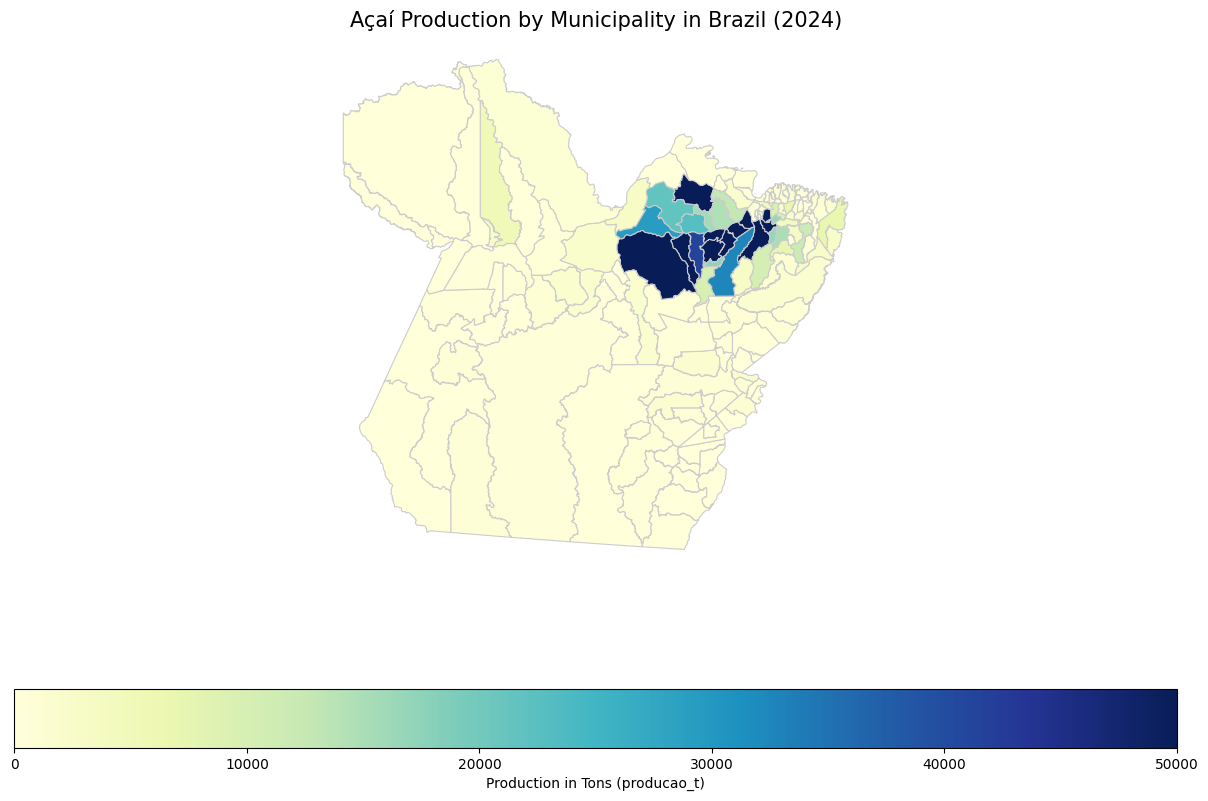

In [38]:
import matplotlib.pyplot as plt

# Create the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf.plot(
    column='producao_t',
    cmap='YlGnBu',  # Choose a color map (Yellow-Green-Blue is good for sequential data)
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Production in Tons (producao_t)", 'orientation': "horizontal"},
    vmax=50000 # Set the maximum value of the color scale
)

ax.set_title('Açaí Production by Municipality in Brazil (2024)', fontsize=15)
ax.set_axis_off() # Remove axes for a cleaner map
plt.show()

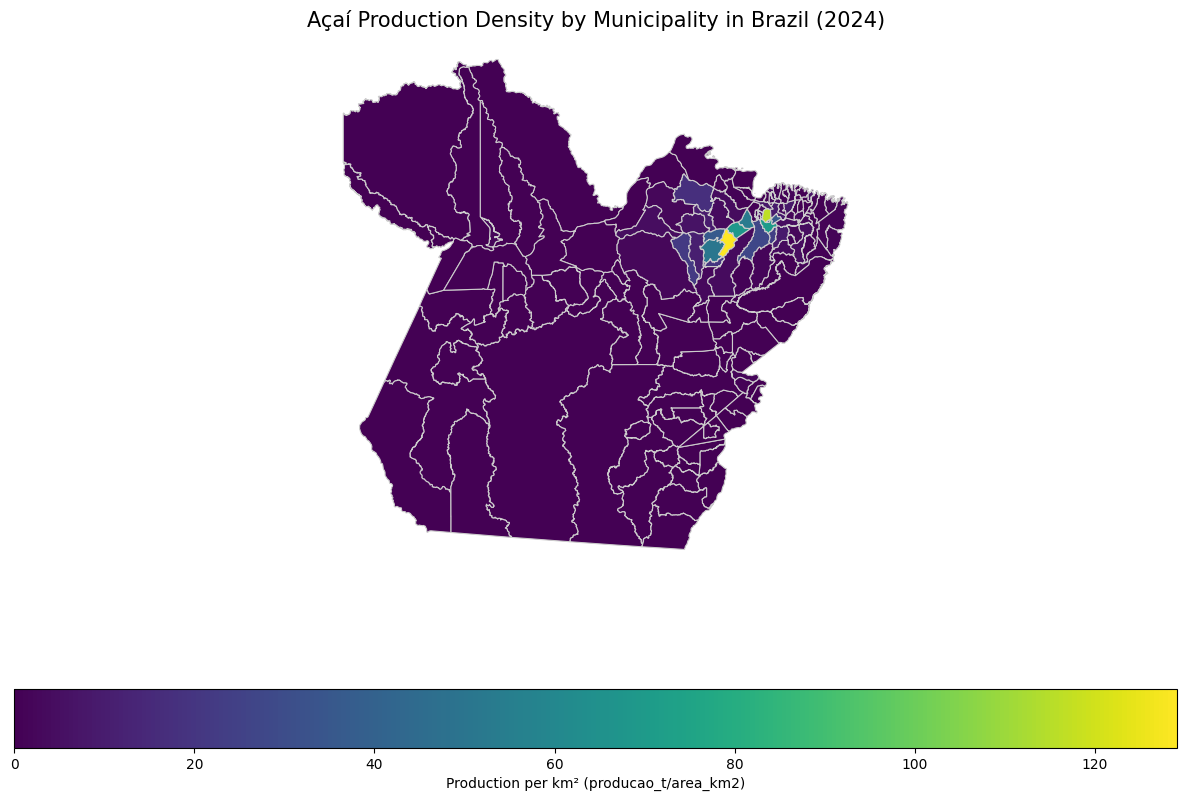

In [39]:
import numpy as np

# Ensure 'area_km2' is available in the gdf.
# First, re-project gdf to a projected CRS for accurate area calculation.
# EPSG:3857 (Web Mercator) is a common choice for global projections and general purpose.
gdf_projected_for_area = gdf.to_crs(epsg=3857)

# Calculate the area in square meters and convert to square kilometers
# geopandas .area returns area in the units of the CRS. For EPSG:3857 (meters), it's m^2.
gdf['area_km2'] = gdf_projected_for_area.geometry.area * 1e-6

# Calculate production per square kilometer
# Handle potential division by zero by replacing infinities with NaN and then filling with 0 if desired.
gdf['producao_per_km2'] = gdf['producao_t'] / gdf['area_km2']
gdf['producao_per_km2'] = gdf['producao_per_km2'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Create the choropleth map for production per km2
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf.plot(
    column='producao_per_km2',
    cmap='viridis', # 'viridis' is a good perceptually uniform colormap
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Production per km² (producao_t/area_km2)", 'orientation': "horizontal"}
)

ax.set_title('Açaí Production Density by Municipality in Brazil (2024)', fontsize=15)
ax.set_axis_off()
plt.show()